In [3]:
!pip install -q \
  "datasets<4.0.0" \
  transformers \
  accelerate \
  evaluate \
  scikit-learn \
  matplotlib \
  fugashi \
  unidic-lite


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 18.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 694.9/694.9 kB 22.7 MB/s eta 0:00:00


In [4]:
import datasets, sys
print("python:", sys.version)
print("datasets:", datasets.__version__)


python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
datasets: 3.6.0


In [5]:
from datasets import load_dataset

ds = load_dataset("shunk031/livedoor-news-corpus", trust_remote_code=True)
ds


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

livedoor-news-corpus.py: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['url', 'date', 'title', 'content', 'category'],
        num_rows: 5894
    })
    validation: Dataset({
        features: ['url', 'date', 'title', 'content', 'category'],
        num_rows: 737
    })
    test: Dataset({
        features: ['url', 'date', 'title', 'content', 'category'],
        num_rows: 736
    })
})

In [6]:
splitted = ds["train"].train_test_split(test_size=0.2, seed=42)
train_ds = splitted["train"]
test_ds  = splitted["test"]

len(train_ds), len(test_ds), train_ds[0]


(4715,
 1179,
 {'url': 'http://news.livedoor.com/article/detail/5962823/',
  'date': '2011-10-24T18:00:00+0900',
  'title': '【ニュース】KDDI社長が喜びの声！iPhone販売は予想以上',
  'content': 'ＫＤＤＩは第２四半期の決算を発表し、iPhone4Sの販売をスタートさせてからの新規契約数が伸びていると発表した。iPhone4Sは予約開始初日に、世界中で殺到し予約台数が100万台を超えたと言われている。  auはちょうど取扱店を全国のauショップへと拡大させる発表をしたばかりだが、今年度のスマートフォンの販売台数は当初より１００万台上も乗せした、５００万台を超えると予想しているということだ。  田中孝司社長はiPhone4Sの販売について「期待以上に好調」だとして、今後さらにスマートフォンのシェア拡大を目指していくということだ。  ＜ＫＤＤＩ＞ｉＰｈｏｎｅ販売「期待以上」\u3000第２四半期決算（毎日新聞）  ■関連記事 ・【話題】タイ洪水被害でパソコン、デジタルカメラ生産に影響 ・【話題】ジョブズ構想のテレビがアップルから登場か ・【ニュース】日本上陸で話題の動画配信サービスHuluがブラビアでも視聴可能に ・ダブルスロットで2枚同時記録可能なHDカメラJVC GY-HM150【ビデオSALON】 ・EOS-1D XでEOS MOVIEは第2章突入か？【ビデオSALON】',
  'category': 2})

In [7]:
# category のユニーク数
num_labels = len(set(train_ds["category"]))
num_labels


8

In [8]:
train_ds.features



{'url': Value(dtype='string', id=None),
 'date': Value(dtype='string', id=None),
 'title': Value(dtype='string', id=None),
 'content': Value(dtype='string', id=None),
 'category': ClassLabel(names=['movie-enter', 'it-life-hack', 'kaden-channel', 'topic-news', 'livedoor-homme', 'peachy', 'sports-watch', 'dokujo-tsushin', 'smax'], id=None)}

In [9]:
train_ds.features


{'url': Value(dtype='string', id=None),
 'date': Value(dtype='string', id=None),
 'title': Value(dtype='string', id=None),
 'content': Value(dtype='string', id=None),
 'category': ClassLabel(names=['movie-enter', 'it-life-hack', 'kaden-channel', 'topic-news', 'livedoor-homme', 'peachy', 'sports-watch', 'dokujo-tsushin', 'smax'], id=None)}

In [10]:
from transformers import AutoTokenizer

MODEL_NAME = "cl-tohoku/bert-base-japanese"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


tokenizer_config.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [11]:
TEXT_COL = "title"
LABEL_COL = "category"

def tokenize_fn(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tok = train_ds.map(tokenize_fn, batched=True)
test_tok  = test_ds.map(tokenize_fn, batched=True)

# Trainer が読む列名を "labels" に合わせる
train_tok = train_tok.rename_column(LABEL_COL, "labels")
test_tok  = test_tok.rename_column(LABEL_COL, "labels")

# 不要列を削る（tokenize したら title/content/url/date は学習に不要）
remove_cols = [c for c in train_tok.column_names if c not in ["input_ids", "attention_mask", "token_type_ids", "labels"]]
train_tok = train_tok.remove_columns(remove_cols)

remove_cols = [c for c in test_tok.column_names if c not in ["input_ids", "attention_mask", "token_type_ids", "labels"]]
test_tok = test_tok.remove_columns(remove_cols)


Parameter 'function'=<function tokenize_fn at 0x78b5282467a0> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/4715 [00:00<?, ? examples/s]

Map:   0%|          | 0/1179 [00:00<?, ? examples/s]

In [12]:
train_tok.column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [13]:
keep_cols = {"input_ids", "attention_mask", "token_type_ids", "labels"}
train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in keep_cols])
test_tok  = test_tok.remove_columns([c for c in test_tok.column_names if c not in keep_cols])


In [14]:
from transformers import AutoModelForSequenceClassification

num_labels = len(set(train_ds["category"]))
MODEL_NAME = "cl-tohoku/bert-base-japanese"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cl-tohoku/bert-base-japanese and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }


In [16]:
from transformers import TrainingArguments, Trainer

args = TrainingArguments(
    output_dir="./outputs",
    eval_strategy="epoch",        # ← ここが変更点
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


/tmp/ipython-input-1978807778.py:18: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [17]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")


CUDA available: True
GPU: Tesla T4


In [18]:
print("train category min/max:", min(train_ds["category"]), max(train_ds["category"]))
print("test  category min/max:", min(test_ds["category"]),  max(test_ds["category"]))
print("train unique:", sorted(set(train_ds["category"])))
print("test  unique:", sorted(set(test_ds["category"])))


train category min/max: 0 7
test  category min/max: 0 7
train unique: [0, 1, 2, 3, 4, 5, 6, 7]
test  unique: [0, 1, 2, 3, 4, 5, 6, 7]


In [19]:
all_labels = sorted(set(train_ds["category"]) | set(test_ds["category"]))
label2id = {lbl:i for i, lbl in enumerate(all_labels)}
id2label = {i:lbl for lbl,i in label2id.items()}
num_labels = len(all_labels)

def remap_labels(example):
    example["category"] = label2id[example["category"]]
    return example

train_ds2 = train_ds.map(remap_labels)
test_ds2  = test_ds.map(remap_labels)

print("num_labels:", num_labels)
print("remapped train unique:", sorted(set(train_ds2["category"])))


Map:   0%|          | 0/4715 [00:00<?, ? examples/s]

Map:   0%|          | 0/1179 [00:00<?, ? examples/s]

num_labels: 8
remapped train unique: [0, 1, 2, 3, 4, 5, 6, 7]


In [20]:
TEXT_COL = "title"
LABEL_COL = "category"

def tokenize_fn(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tok = train_ds2.map(tokenize_fn, batched=True)
test_tok  = test_ds2.map(tokenize_fn, batched=True)

train_tok = train_tok.rename_column(LABEL_COL, "labels")
test_tok  = test_tok.rename_column(LABEL_COL, "labels")

keep_cols = {"input_ids", "attention_mask", "token_type_ids", "labels"}
train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in keep_cols])
test_tok  = test_tok.remove_columns([c for c in test_tok.column_names if c not in keep_cols])


Map:   0%|          | 0/4715 [00:00<?, ? examples/s]

Map:   0%|          | 0/1179 [00:00<?, ? examples/s]

In [21]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "cl-tohoku/bert-base-japanese",
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cl-tohoku/bert-base-japanese and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()


/tmp/ipython-input-263382950.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.614900,0.507695,0.834606,0.830571
2,0.367900,0.396384,0.871925,0.865501
3,0.269700,0.370221,0.886344,0.883026


TrainOutput(global_step=885, training_loss=0.5534372081864352, metrics={'train_runtime': 421.4599, 'train_samples_per_second': 33.562, 'train_steps_per_second': 2.1, 'total_flos': 930476593059840.0, 'train_loss': 0.5534372081864352, 'epoch': 3.0})

In [23]:
final_metrics = trainer.evaluate(test_tok)
final_metrics


{'eval_loss': 0.3702210783958435,
 'eval_accuracy': 0.8863443596268024,
 'eval_f1_macro': 0.8830257846434377,
 'eval_runtime': 9.8435,
 'eval_samples_per_second': 119.775,
 'eval_steps_per_second': 3.759,
 'epoch': 3.0}

<Figure size 800x800 with 0 Axes>

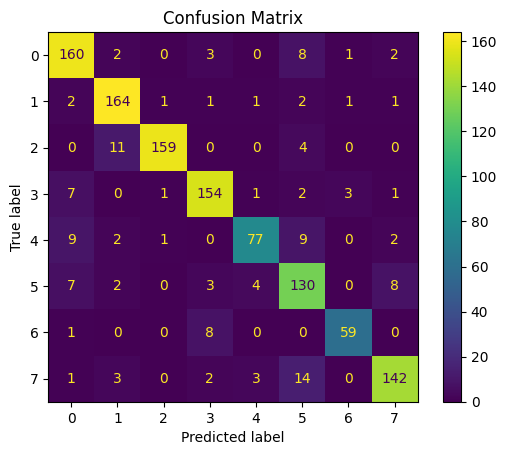

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred = trainer.predict(test_tok)
y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()


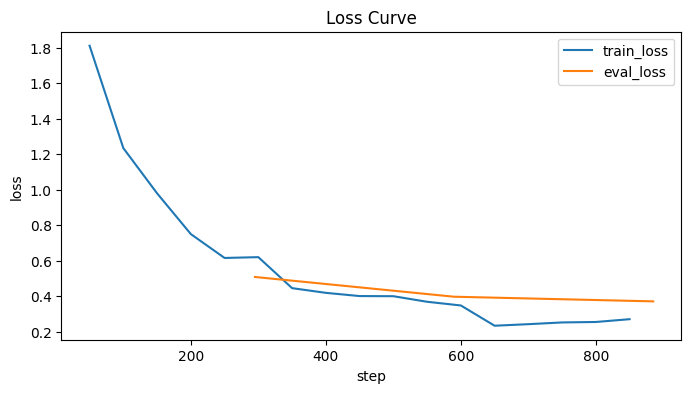

In [25]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history
train_loss = [(x["step"], x["loss"]) for x in logs if "loss" in x and "eval_loss" not in x]
eval_loss  = [(x["step"], x["eval_loss"]) for x in logs if "eval_loss" in x]

plt.figure(figsize=(8, 4))
if train_loss:
    plt.plot([s for s,_ in train_loss], [l for _,l in train_loss], label="train_loss")
if eval_loss:
    plt.plot([s for s,_ in eval_loss], [l for _,l in eval_loss], label="eval_loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Loss Curve")
plt.legend()
plt.show()


In [26]:
SAVE_DIR = "./my_model"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print("saved:", SAVE_DIR)


saved: ./my_model
